[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PerformanceEstimation/Tutorial-SIAM-OP26/blob/main/Part%203%20-%20Dual%2C%20proofs%2C%20and%20design/SIAM_MT_Part2.ipynb)

In [ ]:
!pip install pepit==0.5.1
!pip install sympy

# SIAM OP26 Minitutorial on performance estimation problems (part 2)

This notebook provides:
- two simple examples illustrating how to extract numerical values for the dual variables to analyse **gradient descent** in the smooth and strongly convex setting.
- We show how to search for simplified versions of the proofs, if possible, by explicitly removing certain constraints from the performance estimation problem and by observing they play no role in certain performance guarantees.
- Finally, we show how to leverage those numerical findings to find and verify convergence proofs using SymPy. 

References for the examples are presented at the end.


In [1]:
# import PEPit and the required function class
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction

# import numpy and matplotlib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# set up the smoothness and strong convexity constant for the whole notebook
L, mu = 1, .1

<a id="toc"></a>
## Table of Contents
- [1. Gradient descent, distance to a solution](#example1)
- [2. Gradient descent, function value accuracy](#example2)
- [3. Function values: numerical proof simplification](#example3)
- [4. Using SymPy for the distance analysis](#example4)
- [5. Using SymPy for the function value accuracy analysis](#example5)
- [6. Using symbolic regression (PySR)](#example6)


1. [An optimal multistep gradient descent, design via naive exploration and algebraic observations](#sec1)
2. [An optimal algorithm design for (possibly nonsmooth) convex minimization, design via a conjugate gradient method](#sec2)
3. [An optimal algorithm design for smooth convex minimization, design via a conjugate gradient method](#sec3)
4. [Going further](#sec4)

##  1. Gradient descent, distance to a solution <a class="anchor" id="example1"></a>

### 1.1. Primal PEP (numerical)

We start by a direct attempt: fix class parameters $L,\mu$ (chosen above) and experiment with different step size values $\gamma$. Verify that the obtained convergence rate is indeed smaller than one only when $\gamma\in\left(0,\frac{2}{L}\right)$. Further verify that it matches the very well-known $\max\{(1-\gamma L)^2,(1-\gamma\mu)^2\}$.

In [9]:
def wc_gradient_descent_distance(mu,L,gamma, verbose):
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1) #TODO OPERAND

    # Run n steps of the GD method
    x1 = x0 - gamma * f.gradient(x0)

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( (x1 - xs) ** 2 )

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)

    return pepit_tau, problem._list_of_prepared_constraints # outputs optimal value and list of constraints (with their associated dual variables)

The following pieces of code compute and plot the numerical worst-case guarantees as a function of the tested step size value $\gamma$, for fixed $\mu,L$.

In [10]:
known_worst_case_value_function = lambda gamma: max((1 - gamma * L)**2, (1 - gamma * mu)**2)

In [13]:
verbose = 0

gamma_min, gamma_max = -1, 3
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, _ = wc_gradient_descent_distance(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(known_worst_case_value_function(gamma))

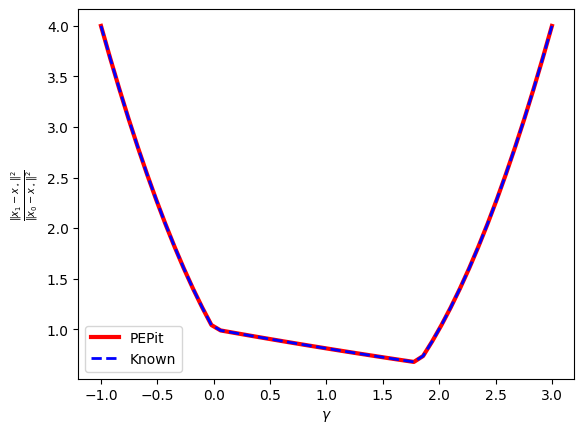

In [14]:
plt.plot(gamma_list, pepit_worst_case_value, color='red', linestyle='-', linewidth=3, label='PEPit')
plt.plot(gamma_list, known_worst_case_value, color='blue', linestyle='--', linewidth=2, label='Known')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\frac{\|x_1 - x_\star\|^2}{\|x_0 - x_\star\|^2}$')

plt.show()

One can admit that the match between PEPit's results and the known convergence rate is pretty good.

### 1.2. Dual PEP (numerical)

Let us also extract the dual variables. The next lines examplify how to do this extraction for given values of the parameters, and we integrate it in a loop for plotting below.

In [15]:
verbose = 0
gamma = 1/L

pepit_tau, list_of_constraints = wc_gradient_descent_distance(mu,L,gamma, verbose)

nb_cons = len(list_of_constraints)

for i in range(nb_cons):
    print('Constraint \"{}\" value: {}'.format(list_of_constraints[i].get_name(),
                                               list_of_constraints[i]._dual_variable_value))

Constraint "Performance metric 1" value: 1.0
Constraint "Initial condition" value: 0.8100000006611664
Constraint "IC_Function_0_smoothness_strong_convexity(Point_0, Point_1)" value: 1.800009898700675
Constraint "IC_Function_0_smoothness_strong_convexity(Point_1, Point_0)" value: 1.800009898700675


One can observe that the performance estimation problem is actually involving 4 constraints, 2 of which are of interest for us: the 3rd and 4th ones (that encode the fact the function is smooth and strongly convex). We can therefore extract their values in a loop, plot them, and expect their closed-forms to be nice. Perhaps one could even guess their values.

In [20]:
verbose = 0

gamma_min, gamma_max = -1, 3
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
pepit_dual_value1 = list()
pepit_dual_value2 = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, list_of_constraints = wc_gradient_descent_distance(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(max((1-gamma*L)**2,(1-gamma*mu)**2))
    pepit_dual_value1.append(list_of_constraints[2]._dual_variable_value)
    pepit_dual_value2.append(list_of_constraints[3]._dual_variable_value)

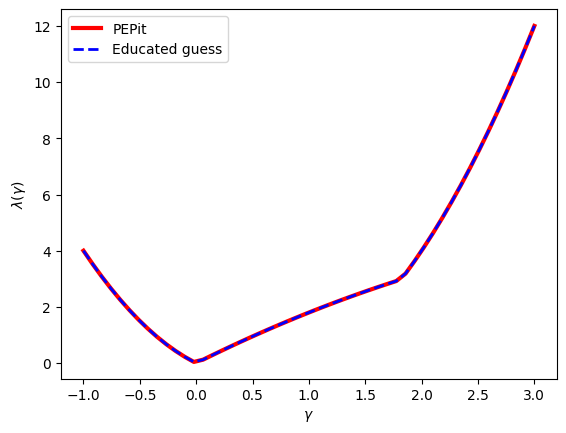

In [21]:
candidate_lambda_value = lambda gamma: max(abs(1-gamma*L),abs(1-gamma*mu))*2*abs(gamma)


candidate_lambda_list = [ candidate_lambda_value(gamma) for gamma in gamma_list ]
plt.plot(gamma_list, pepit_dual_value1, color='red', linestyle='-', linewidth=3, label='PEPit')
plt.plot(gamma_list, candidate_lambda, color='blue', linestyle='--', linewidth=2, label='Educated guess')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\lambda(\gamma)$')

plt.show()

### 1.3. Dual PEP (symbolic)

This section requires [Sympy](https://www.sympy.org/en/index.html) (should have been installed in the beginning of the notebook via 
!pip install sympy).

In [23]:
import sympy as sm

#### Forming the LMI

First, we introduce symbols for the parameters

In [27]:
# create symbols for the problem parameters:
L = sm.Symbol('L')
mu = sm.Symbol('mu')
gamma = sm.Symbol('gamma')

Then, we introduce temporary symbols for the 'primal variables':

In [28]:
# create symbols for the "primal" variables:
x0 = sm.Symbol('x0')
g0 = sm.Symbol('g0')
f0 = sm.Symbol('f0')
xs = 0 # wlog, x_* = 0
gs = 0 # constraint g_* = 0
fs = 0 # wlog, f_* = 0

# define x1 using previous symbols:
x1 = x0 - gamma * g0  #TODO OPERAND

Then, we introduce the constraints and dual variables:

In [44]:
# the two interpolation constraints in the form "constraint <= 0"
constraint1 = f0 - fs + g0*(xs-x0) + 1/2/L * g0**2 + mu/(2*(1-mu/L)) * (x0-xs-1/L*g0)**2
constraint2 = fs - f0 + 1/2/L * g0**2 + mu/(2*(1-mu/L)) * (x0-xs-1/L*g0)**2
# the objective and the "initial condition" constraint: (also in the form "constraint <= 0")
primal_objective = (x1-xs)**2
initial_condition = (x0-xs)**2-1

# create symbols for the "dual" variables
tau = sm.Symbol('tau')
l1 = sm.Symbol('lambda_1')
l2 = sm.Symbol('lambda_2')

Finally, we write the Lagrangian

In [45]:
# Lagrangian:
Lagrangian = primal_objective - l1*constraint1 - l2*constraint2 - tau * initial_condition

Since our expressions are quadratic in (x0,g0), the LMI is actually given by the Hessian of the Lagrangian wrt (x0,g0).
Alternatively, one can compute the matrices $A_i$ and vectors $b_i$ that would encode the constraints as $\mathrm{Tr}(A_i G)+b_i^T F\leq 0$.

In [46]:
# This is the LMI:
LMI = sm.simplify(sm.hessian( -Lagrangian , (x0,g0))/2)


LMI # Should this matrix be PSD or NSD?

Matrix([
[(L*lambda_1*mu/2 + L*lambda_2*mu/2 + (L - mu)*(tau - 1))/(L - mu),         (-L*lambda_1/2 + gamma*(L - mu) - lambda_2*mu/2)/(L - mu)],
[        (-L*lambda_1/2 + gamma*(L - mu) - lambda_2*mu/2)/(L - mu), (4*gamma**2*(-L + mu) + 2.0*lambda_1 + 2.0*lambda_2)/(4*(L - mu))]])

Similarly, the linear constraint on the dual is the gradient wrt f0 (since $f_\star$ is fixed to $0$)

In [47]:
# This is the linear constraint ==0 in the LMI
LinearConst = sm.simplify(sm.diff(-Lagrangian,f0))

LinearConst # show linear constraint (==0)

lambda_1 - lambda_2

#### Verify that our candidate multipliers produce dual feasible points

For simplicity, set $\gamma=\tfrac1L$. What are the corresponding values for your candidates $\tau$ and $\lambda_1,\lambda_2$?

In [62]:
# Specialize the LMI to gamma=1/L

fixed_gamma = 1/L
LMI_fixed_gamma = sm.simplify(LMI.subs(gamma,fixed_gamma))

LMI_fixed_gamma

Matrix([
[(L*lambda_1*mu/2 + L*lambda_2*mu/2 + (L - mu)*(tau - 1))/(L - mu),   (-L*(L*lambda_1 + lambda_2*mu)/2 + L - mu)/(L*(L - mu))],
[          (-L*(L*lambda_1 + lambda_2*mu)/2 + L - mu)/(L*(L - mu)), (0.5*L**2*(lambda_1 + lambda_2) - L + mu)/(L**2*(L - mu))]])

In [63]:
# Specialize the LMI to gamma=1/L

candidate_expression_lambda = 2 * fixed_gamma * (1 - mu * fixed_gamma)
candidate_expression_tau = (1 - mu * fixed_gamma )**2

LMI_simplified = sm.simplify(LMI_fixed_gamma.subs(l2,l1))
LMI_simplified = sm.simplify(LMI_simplified.subs(l1,candidate_expression_lambda))
LMI_simplified = sm.simplify(LMI_simplified.subs(tau,candidate_expression_tau))
LMI_simplified

Matrix([
[mu**2/L**2, -mu/L**2],
[  -mu/L**2, 1.0/L**2]])

Is this matrix PSD? What do we conclude?

In [64]:
LMI_simplified.eigenvals()

{1.0*(mu**2 + 1)/L**2: 1, 0: 1}

### 1.4. Equivalent proof without SDPs

In [67]:
# problem parameters
L, mu, gamma = sm.symbols('L mu gamma')

# primal variables
x0, g0, f0 = sm.symbols('x0 g0 f0')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero

# dual variables
tau = (1 - mu * gamma)**2
l1 = 2 * gamma * (1 - mu * gamma)
l2 = l1

# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fi - fj + gi*(xj-xi) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)

# algorithm (GD)
x1 = x0 - gamma * g0

# constraints (≤ 0)
constraint1 = interp_ij(x0, g0, f0, xs, gs, fs)
constraint2 = interp_ij(xs, gs, fs, x0, g0, f0)

# objective and initial condition
performance_measure = (x1 - xs)**2
initial_condition = (x0 - xs)**2 

# Weighted sum
weighted_sum = l1 * constraint1 + l2 * constraint2

# Reformulation
reformulation = performance_measure - tau * initial_condition + gamma * (2 - gamma * (L + mu))/(L - mu) * (mu * (x0 - xs) - g0)**2

# Verify equivalence
residual = sm.simplify(weighted_sum - reformulation)
residual

0

##  2. Gradient descent, function value accuracy <a class="anchor" id="example2"></a>

Let us continue with the a similar exercise, but now by changing the specific quantity under our radar to function values. Practically speaking, this means changing both the performance metric and the initial condition in the previous code. Executing the code in the same fashion as before, we observe the exact same worst-case ratios.

In [5]:
def wc_gradient_descent_function_values(mu, L, gamma, verbose):
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition( f(x0) - fs <= 1) #TODO OPERAND

    # Run n steps of the GD method
    x1 = x0 - gamma * f.gradient(x0)

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( f(x1) - fs )

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)

    return pepit_tau, problem._list_of_prepared_constraints # outputs optimal value and list of constraints (with their associated dual variables)

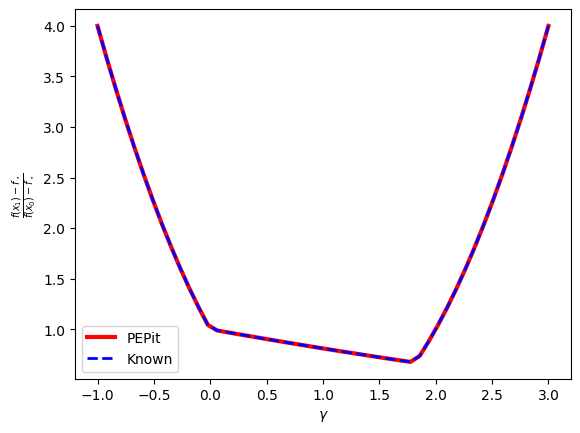

In [6]:
verbose = 0

gamma_min, gamma_max = -1, 3
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, _ = wc_gradient_descent_function_values(mu, L, gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(max((1-gamma*L)**2,(1-gamma*mu)**2))

plt.plot(gamma_list, pepit_worst_case_value, color='red', linestyle='-', linewidth=3, label='PEPit')

plt.plot(gamma_list, known_worst_case_value, color='blue', linestyle='--', linewidth=2, label='Known')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\frac{f(x_1) - f_\star}{f(x_0) - f_\star}$')

plt.show()

However, a bad surprise appears when inspecting the problem: there are actually more constraints, and hence possibly more dual multipliers to be identified. We do not describe here the reason for this difference (more constraints, explained at length, e.g., in [this blog post](https://francisbach.com/computer-aided-analyses/) or this [habilitation thesis](https://hal.science/tel-04794552v2/file/HDR_ATaylor_V_HAL2.pdf)) and instead focus on the consequences. First, let us investigate a bit the values of those (additional) dual variables.

In [7]:
verbose = 0
gamma = 1/L

pepit_tau, list_of_constraints = wc_gradient_descent_function_values(mu,L,gamma, verbose)

nb_cons = len(list_of_constraints)

for i in range(nb_cons):
    print('Constraint \"{}\" value: {}'.format(list_of_constraints[i].get_name(),
                                               list_of_constraints[i]._dual_variable_value))

Constraint "Performance metric 1" value: 1.0
Constraint "Initial condition" value: 0.8099999034654997
Constraint "IC_Function_0_smoothness_strong_convexity(Point_0, Point_1)" value: 0.04318494581205349
Constraint "IC_Function_0_smoothness_strong_convexity(Point_0, Point_2)" value: 0.14690493317815176
Constraint "IC_Function_0_smoothness_strong_convexity(Point_1, Point_0)" value: 3.7068368407529674e-05
Constraint "IC_Function_0_smoothness_strong_convexity(Point_1, Point_2)" value: 1.3215023299277147
Constraint "IC_Function_0_smoothness_strong_convexity(Point_2, Point_0)" value: 5.272685701848342e-05
Constraint "IC_Function_0_smoothness_strong_convexity(Point_2, Point_1)" value: 0.46835454902147894


To get a clearer picture, let us plot all these values as a function of $\gamma$ again. The code below is intentionally a bit raw for readability purposes---there are six dual variables to explore.

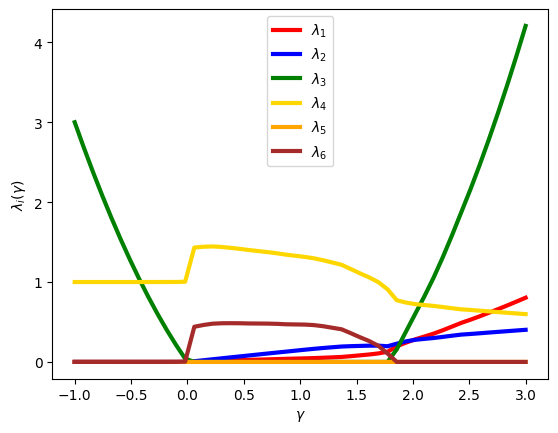

Well, guessing closed-forms appears like a much more challenging game! Before actually going into the search for closed-forms, we need to simplify the problem; this is not done here, but the interested reader can check [this more complete notebook (Section 3)](https://github.com/PerformanceEstimation/PEPit/blob/master/ressources/demo/PEPit_demo_extracting_a_proof.ipynb).